In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

pd.set_option('display.width', 1000)
pd.read_csv('../stats-all-latest.csv').to_pickle('../stats-all-latest.pkl')

In [2]:
from datetime import datetime as dt

pickle_df = pd.read_pickle('../stats-all-latest.pkl')
millis_in_day = 1000 * 60 * 60 * 24
# expected_datapoints_in_day = 24 * 12 * 2 * 2 * 3 * 3 * 3 # hours * executions * clouds * images * formats * widths * memory

# First and last executions, timestamp is in millis
min_ts = pickle_df["timestamp"].min()
max_ts = pickle_df["timestamp"].max()
day_0 = min_ts - min_ts % millis_in_day
start_offset_days = 0
start_ts = day_0 + millis_in_day * start_offset_days

print(f'Day 0 start:      {dt.fromtimestamp(day_0/1000)}')
print(f'First timestamp:  {dt.fromtimestamp(min_ts/1000)}')
if (start_offset_days > 0):
    print(f'Experiment start: {dt.fromtimestamp(start_ts/1000)} {start_offset_days} days later') 
print(f'Last timestamp:   {dt.fromtimestamp(max_ts/1000)}')

# Drop measurements from day 0
df = pickle_df.loc[(pickle_df['timestamp'] >= start_ts)].copy()
print(f'Datapoints from start timestamp onwards: {len(df)}')

Day 0 start:      2024-12-02 00:00:00
First timestamp:  2024-12-02 18:40:58.296000
Last timestamp:   2024-12-20 22:56:08.733000
Datapoints from start timestamp onwards: 562245


#### Handler counts by cloud

                               mean   p50   p95   p99  max
providerMemoryAssociated                                  
885                       12.566776  12.0  24.0  27.0   32
1769                      12.581235  12.0  24.0  27.0   43
3538                      12.550726  12.0  24.0  27.0   28


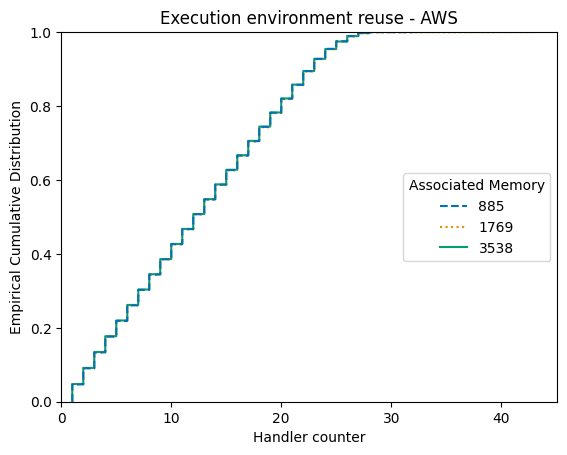

                                mean    p50      p95      p99   max
providerMemoryAssociated                                           
885                       670.182139  550.0  1704.85  1987.97  2306
1769                      700.617297  587.0  1711.00  1901.00  2303
3538                      673.024368  551.0  1718.00  2085.00  2300


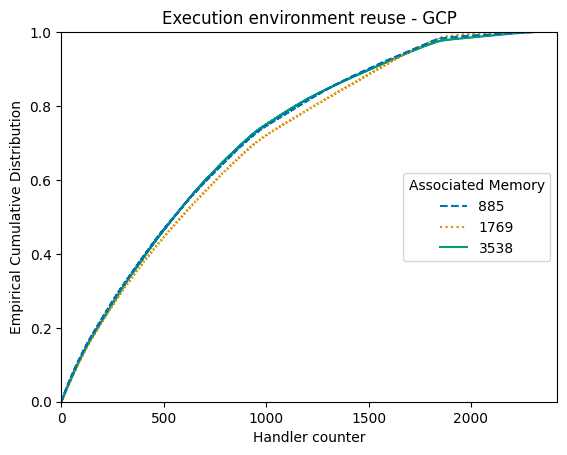

In [12]:
import seaborn as sns

for cloud in ["aws", "gcp"]:
    data = df.loc[(df["providerName"] == cloud)]
    print(data.groupby(["providerMemoryAssociated"]).agg(
        mean=('handlerCount', 'mean'),
        p50=('handlerCount', lambda x: x.quantile(0.50)),
        p95=('handlerCount', lambda x: x.quantile(0.95)),
        p99=('handlerCount', lambda x: x.quantile(0.99)),
        max=('handlerCount', 'max')
    ))

    ax = sns.ecdfplot(
        data,
        x="handlerCount",
        hue="providerMemoryAssociated",
        # multiple="dodge",
        palette="colorblind",
    )

    # Change linestyle
    lss = ["solid", "dotted", "dashed"]
    handles = ax.legend_.legend_handles[::-1]

    for line, ls, handle in zip(ax.lines, lss, handles):
        line.set_linestyle(ls)
        handle.set_ls(ls)

    ax.get_legend().set_title("Associated Memory")
    plt.title(f"Execution environment reuse - {cloud.upper()}")
    plt.ylabel("Empirical Cumulative Distribution")
    plt.xlabel("Handler counter")
    plt.xlim(0,)
    sns.move_legend(ax, "center right")
    ax.get_figure().savefig(f'../graphs/1-handler-counts-{cloud}.pdf', bbox_inches='tight')
    plt.show()
    plt.close()